# Short Term Memory

In [47]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.messages.utils import trim_messages, count_tokens_approximately


In [48]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [49]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000,
        tiktoken_model_name="gpt-4o"
    )

llm = get_groq_llm()

In [50]:
class AgentState(MessagesState):
    user_name: str
    current_topic: str

In [51]:
def extract_facts(state: AgentState):
    """This node quietly reads the latest message and updates the dashboard."""
    latest_msg = state["messages"][-1].content

    print("\n[🧠 FACT EXTRACTOR RUNNING...]")

    # We ask the LLM to pull out facts quickly
    prompt = f"""
    Read the user's message and extract two things:
    1. Their name (if mentioned). If not, reply "Unknown".
    2. The main topic they are talking about.

    User Message: "{latest_msg}"

    Reply ONLY in this exact format:
    Name: [Name]
    Topic: [Topic]
    """

    response = llm.invoke([HumanMessage(content=prompt)]).content

    # Parse the text to update our state variables
    new_name = state.get("user_name", "Unknown")
    new_topic = state.get("current_topic", "General")

    for line in response.split('\n'):
        if line.startswith("Name:") and "Unknown" not in line:
            new_name = line.replace("Name:", "").strip()
        if line.startswith("Topic:"):
            new_topic = line.replace("Topic:", "").strip()

    print(f" -> Dashboard Updated | Name: {new_name} | Topic: {new_topic}")

    # Update the graph's memory with these concrete facts
    return {"user_name": new_name, "current_topic": new_topic}

In [52]:
def chat(state: AgentState):
    print("[🗣️ CHAT NODE RUNNING...]")

    # 1. Read the Dashboard facts
    name = state.get("user_name", "Friend")
    topic = state.get("current_topic", "General")

    # 2. Build a highly specific System Prompt
    sys_msg = SystemMessage(
        content=f"You are a helpful assistant. "
                f"Address the user as '{name}'. "
                f"Keep answers brief. The current topic is: {topic}."
    )

    # 3. Brutally trim the history!
    # Because our facts are safe in the dashboard, we only need the last 2 messages for flow!
    trimmed_history = trim_messages(
        state["messages"],
        max_tokens=100, # Ultra short limit
        strategy="last",
        token_counter=count_tokens_approximately,
    )

    # 4. Sandwich it and generate
    response = llm.invoke([sys_msg] + trimmed_history)
    return {"messages": [response]}

In [53]:
builder = StateGraph(AgentState)

# Notice the flow: User -> Extractor -> Chat -> End
builder.add_node("extract_facts", extract_facts)
builder.add_node("chat", chat)

builder.add_edge(START, "extract_facts")
builder.add_edge("extract_facts", "chat")
builder.add_edge("chat", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

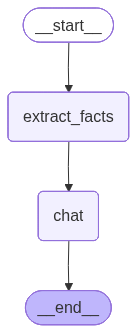

In [54]:
graph

In [55]:
config = {"configurable": {"thread_id": "structured-memory-demo"}}

In [56]:
print("=== Starting Structured Memory Chat ===")
questions = [
    "Hi, my name is Arthur.",
    "I am trying to learn how to bake a chocolate cake.",
    "What was my name again?",
    "What are we talking about right now?"
]

for q in questions:
    print(f"\nUser: {q}")
    result = graph.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f"Bot: {result['messages'][-1].content}")

=== Starting Structured Memory Chat ===

User: Hi, my name is Arthur.

[🧠 FACT EXTRACTOR RUNNING...]
 -> Dashboard Updated | Name: Arthur | Topic: Unknown
[🗣️ CHAT NODE RUNNING...]
Bot: Hello, Arthur! How can I help you today?

User: I am trying to learn how to bake a chocolate cake.

[🧠 FACT EXTRACTOR RUNNING...]
 -> Dashboard Updated | Name: Arthur | Topic: baking a chocolate cake
[🗣️ CHAT NODE RUNNING...]
Bot: Sure thing, Arthur! Here’s a quick, fool‑proof chocolate cake recipe:

**Ingredients**  
- 1 ½ cups all‑purpose flour  
- 1 cup sugar  
- ½ cup cocoa powder (unsweetened)  
- 1 tsp baking soda  
- ½ tsp baking powder  
- ½ tsp salt  
- 1 egg + 1 egg yolk (reserve yolk for frosting)  
- 1 cup buttermilk (or 1 cup milk + 1 tsp vinegar)  
- ½ cup vegetable oil  
- 2 tsp vanilla  
- 1 cup hot water

**Directions**  
1. Preheat oven to 350 °F (175 °C). Grease & flour a 9‑inch round pan.  
2. In a large bowl whisk flour, sugar, cocoa, baking soda, powder, salt.  
3. Beat egg, yolk, 